<a href="https://colab.research.google.com/github/Nicolas-Bernal/Simulacion-Estadistica/blob/main/Segundo%20Corte/02_Multivariado.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Librerias necesarias


install.packages("plot3D")
require("plot3D")

install.packages("ks")
require("ks")



Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependency ‘misc3d’


Loading required package: plot3D

Warning message:
“no DISPLAY variable so Tk is not available”
Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘FNN’, ‘kernlab’, ‘mclust’, ‘multicool’, ‘mvtnorm’, ‘pracma’


Loading required package: ks



# Metodo Aceptacion y rechazo Multivariado


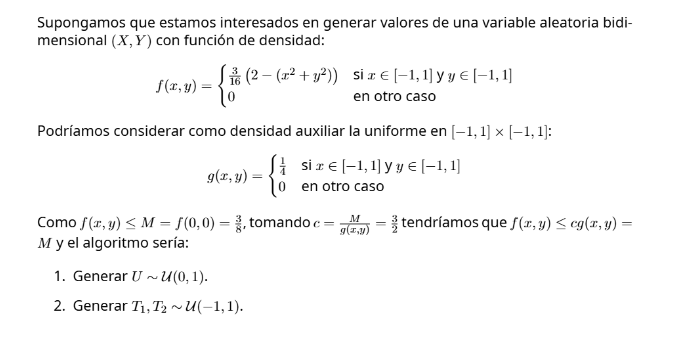

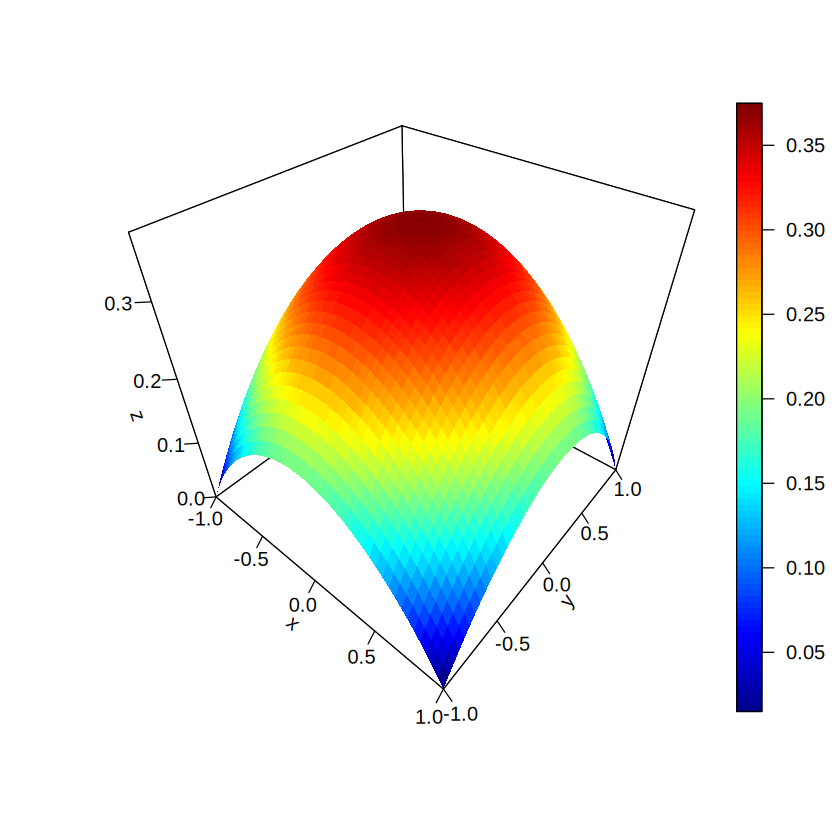

In [3]:
## Metodo Aceptacion y Rechazo Multivariado

f = function(x,y){
  3 * (2 - x^2 - y^2) / 16
}

persp.f2D = function(f2d,ax = 1,bx = 1,ay = 1,by = 1, nx = 21, ny =21, ...){
  x = seq(ax,bx,length = nx)
  y = seq(ay,by,length = ny)
  z = outer(x,y,f2d)

  plot3D::persp3D(x,y,z,...)
}

persp.f2D(f,-1,1,-1,1,50,50, ticktype = "detailed")

In [5]:
# Ahora con lo anterior tenemos que implementar el algoritmo de aceptacion y rechazo

ngen = 0

rf = function(){
  # simulacion por aceptacion y rechazo apartir de uniforme

  m = 3/8

  while(TRUE){
    u = runif(1)
    x = runif(2,-1,1)
    ngen <<- ngen + 1
    if (m * u <= f(x[1],x[2])){
      return(x)
    }
  }
}

In [4]:
# Funcion para generar n valores

rfn = function(n = 1000){
  ngen <<- 0
  # Simulacion n valores

  x = matrix(nrow = n,ncol = 2)
  for(i in 1:n){
    x[i, ] = rf()
  }
  return(x)
}

   user  system elapsed 
  0.022   0.000   0.023 

 Numero de generaciones =  3011
 Numero medio de generaciones =  1.5055
 Proporcion de rechazos =  0.3357688 


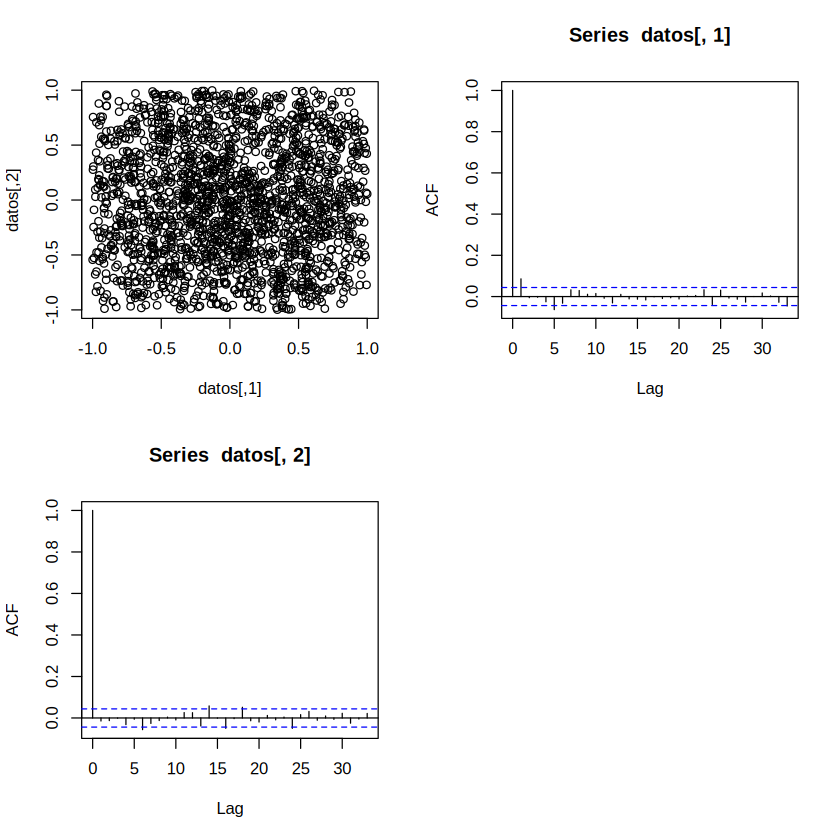

In [6]:
set.seed(1)
nsim = 2000
datos = rfn(nsim)

system.time(rfn(nsim))

par(mfrow = c(2,2))

plot(datos)

acf(datos[,1])
acf(datos[,2])

cat(" Numero de generaciones = ", ngen)
cat("\n Numero medio de generaciones = ", ngen /nsim)
cat("\n Proporcion de rechazos = ", 1 - nsim/ngen,"\n")

In [7]:
# Valor de C teorico se consigue en el archivo que lo encontramos

c = 3/2 ### M/g(x,y), f(x,y) <= M
c
1 - 1/c # lo cual coincide con el

[1] 1.5

[1] 0.3333333

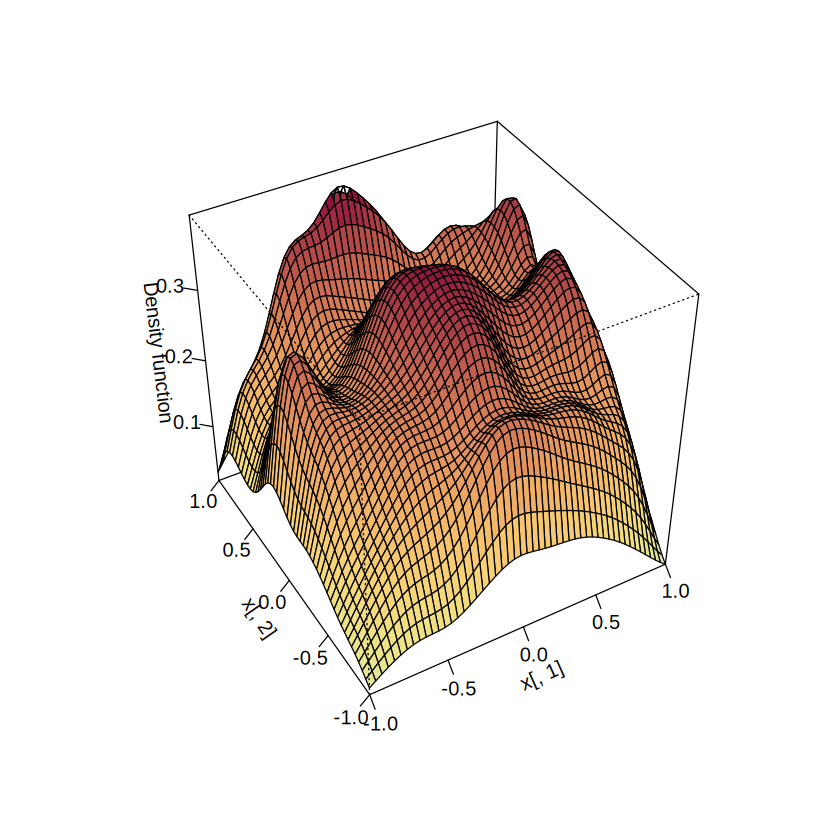

In [8]:
H_matrix <- Hpi(datos)
fhat = kde.boundary(datos, xmin = c(-1,-1), xmax = c(1,1) , boundary.kernel = "linear")
plot(fhat,display = "persp")

In [9]:
nsim = 20

n = 100

t = seq(0,1,length = n)

# media

mu = sin(2*pi*t)

# covarianza

t.dist = as.matrix(dist(t))
x.cov = exp(-t.dist)
head(x.cov)

,1,2,3,4,5,6,7,8,9,10,⋯,91,92,93,94,95,96,97,98,99,100
1,1.0000000,0.9899498,0.9800007,0.9701515,0.9604013,0.9507491,0.9411939,0.9317348,0.9223707,0.9131007,⋯,0.4028903,0.3988412,0.3948328,0.3908647,0.3869364,0.3830476,0.3791979,0.3753869,0.3716142,0.3678794
2,0.9899498,1.0000000,0.9899498,0.9800007,0.9701515,0.9604013,0.9507491,0.9411939,0.9317348,0.9223707,⋯,0.4069805,0.4028903,0.3988412,0.3948328,0.3908647,0.3869364,0.3830476,0.3791979,0.3753869,0.3716142
3,0.9800007,0.9899498,1.0000000,0.9899498,0.9800007,0.9701515,0.9604013,0.9507491,0.9411939,0.9317348,⋯,0.4111123,0.4069805,0.4028903,0.3988412,0.3948328,0.3908647,0.3869364,0.3830476,0.3791979,0.3753869
4,0.9701515,0.9800007,0.9899498,1.0000000,0.9899498,0.9800007,0.9701515,0.9604013,0.9507491,0.9411939,⋯,0.4152860,0.4111123,0.4069805,0.4028903,0.3988412,0.3948328,0.3908647,0.3869364,0.3830476,0.3791979
5,0.9604013,0.9701515,0.9800007,0.9899498,1.0000000,0.9899498,0.9800007,0.9701515,0.9604013,0.9507491,⋯,0.4195020,0.4152860,0.4111123,0.4069805,0.4028903,0.3988412,0.3948328,0.3908647,0.3869364,0.3830476
6,0.9507491,0.9604013,0.9701515,0.9800007,0.9899498,1.0000000,0.9899498,0.9800007,0.9701515,0.9604013,⋯,0.4237609,0.4195020,0.4152860,0.4111123,0.4069805,0.4028903,0.3988412,0.3948328,0.3908647,0.3869364


In [10]:
# luego aplicamos la factorizacion de cholesky

u = chol(x.cov) ### eigen(), svd(), chol()

l = t(u)
head(l)  ### es una matriz superior

,1,2,3,4,5,6,7,8,9,10,⋯,91,92,93,94,95,96,97,98,99,100
1,1.0000000,0.0000000,0.0000000,0.0000000,0.0000000,0.000000,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
2,0.9899498,0.1414190,0.0000000,0.0000000,0.0000000,0.000000,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
3,0.9800007,0.1399977,0.1414190,0.0000000,0.0000000,0.000000,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
4,0.9701515,0.1385907,0.1399977,0.1414190,0.0000000,0.000000,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
5,0.9604013,0.1371978,0.1385907,0.1399977,0.1414190,0.000000,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
6,0.9507491,0.1358190,0.1371978,0.1385907,0.1399977,0.141419,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0


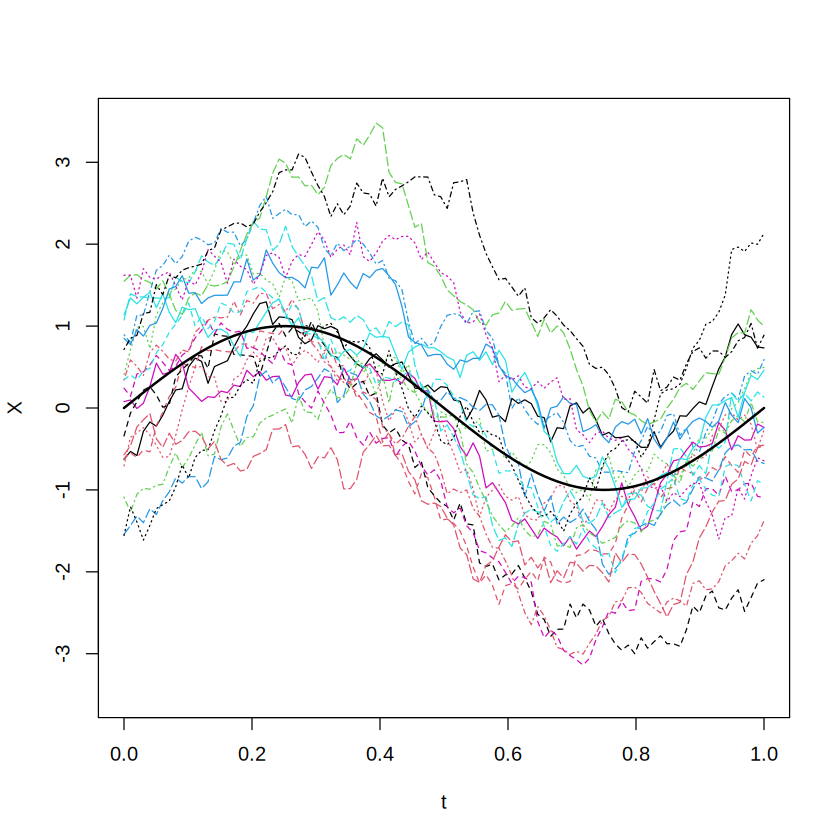

In [11]:
set.seed(1)
z = matrix(rnorm(nsim * n), nrow = n)

X = mu + l %*% z

matplot(t,X,type = "l", ylim = c(-3.5,3.5))
lines(t,mu,lwd = 2) # encontrol de calidad se usa bastante este tipo de datos ya que se trabajan datos no lineales

In [12]:
# para generar estos tipo de numeros podemos usar que

library(MASS)

mvrnorm

x = mvrnorm(nsim,mu,x.cov)

function (n = 1, mu, Sigma, tol = 1e-06, empirical = FALSE, EISPACK = FALSE) 
{
    p <- length(mu)
    if (!all(dim(Sigma) == c(p, p))) 
        stop("incompatible arguments")
    if (EISPACK) 
        stop("'EISPACK' is no longer supported by R", domain = NA)
    eS <- eigen(Sigma, symmetric = TRUE)
    ev <- eS$values
    if (!all(ev >= -tol * abs(ev[1L]))) 
        stop("'Sigma' is not positive definite")
    X <- matrix(rnorm(p * n), n)
    if (empirical) {
        X <- scale(X, TRUE, FALSE)
        X <- X %*% svd(X, nu = 0)$v
        X <- scale(X, FALSE, TRUE)
    }
    X <- drop(mu) + eS$vectors %*% diag(sqrt(pmax(ev, 0)), p) %*% 
        t(X)
    nm <- names(mu)
    if (is.null(nm) && !is.null(dn <- dimnames(Sigma))) 
        nm <- dn[[1L]]
    dimnames(X) <- list(nm, NULL)
    if (n == 1) 
        drop(X)
    else t(X)
}
<bytecode: 0x5718e0115c38>
<environment: namespace:MASS>